In [71]:
# Φόρτωση απαραίτητων βιβλιοθηκών για τα κελιά
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

<center><h3>1. Φόρτωση του Αρχείου products-1000.csv</h3></center>

In [72]:
# Ερώτημα 1: Φόρτωση του αρχείου products-1000.csv

# Φόρτωση του αρχείου products-1000.csv από https://github.com/datablist/sample-csv-files
url = "https://drive.google.com/uc?id=1aZNLCVO0VoHmvPNvSC2teeFmZfiViE6u&export=download"

# Φόρτωση του αρχείου σε ένα pandas DataFrame
df = pd.read_csv(url)

# Επιβεβαίωση ότι το αρχείο φορτώθηκε επιτυχώς με ένα μήνυμα και εκτύπωση του αριθμού των γραμμών και των πρώτων 5 γραμμών για επικύρωση
print(f"\nΕπιτυχής φόρτωση! Το αρχείο έχει {len(df)} γραμμές και οι 5 πρώτες είναι:")
df.head()


Επιτυχής φόρτωση! Το αρχείο έχει 1000 γραμμές και οι 5 πρώτες είναι:


,Index,Name,Description,Brand,Category,Price,Currency,Stock,EAN,Color,Size,Availability,Internal ID
0,1,Thermostat Drone Heater,Consumer approach woman us those star.,Bradford-Yu,Kitchen Appliances,74,USD,139,8619793560985,Orchid,Medium,backorder,38
1,2,Ultra Speaker Iron Grill Advanced One,Point suggest easy money operation could white.,Douglas Group,Fitness Equipment,510,USD,351,3057216124300,MediumSeaGreen,Small,backorder,27
2,3,Watch Headphones Kettle,Reach husband education.,Landry-Austin,Beauty & Personal Care,254,USD,409,9825254410556,Lavender,XXL,pre_order,2
3,4,Portable Toaster Clock Monitor Silent,Always choose school poor table main.,"Odom, Norton and Foster",Makeup,69,USD,119,9490814777808,Pink,XL,in_stock,94
4,5,Pro Toaster Oven,Worry put discuss easy back too career.,"Fowler, Mendoza and Mcdaniel",Automotive,525,USD,727,4726650403799,LightCoral,XL,in_stock,95


<center><h3>2. Εκτύπωση Πρώτων 10 Σειρών</h3></center>

In [73]:
# Ερώτημα 2: Εκτύπωση των 10 πρώτων σειρών
print(df.head(10))

   Index                                        Name  \
0      1                     Thermostat Drone Heater   
1      2       Ultra Speaker Iron Grill Advanced One   
2      3                     Watch Headphones Kettle   
3      4       Portable Toaster Clock Monitor Silent   
4      5                            Pro Toaster Oven   
5      6                     Mini Speakerphone Mixer   
6      7      Eco Cooler Printer Speaker Prime Prime   
7      8                    Webcam Trimmer Projector   
8      9  Silent Headphones Stove Wireless Air Clean   
9     10          Wireless Charger Air Premium Ultra   

                                         Description  \
0             Consumer approach woman us those star.   
1    Point suggest easy money operation could white.   
2                           Reach husband education.   
3              Always choose school poor table main.   
4            Worry put discuss easy back too career.   
5       Tell figure discussion chair red keep t

<center><h3>3. Συνοπτικά Στατιστικά των Αριθμητικών Στηλών</h3></center>

In [74]:
# Ερώτημα 3: Εκτύπωση συνοπτικών στατιστικών για τις στήλες με αριθμούς
print(df.describe())

             Index        Price        Stock           EAN  Internal ID
count  1000.000000  1000.000000  1000.000000  1.000000e+03  1000.000000
mean    500.500000   506.549000   501.782000  5.130255e+12    47.690000
std     288.819436   283.773556   292.151318  2.907413e+12    28.984202
min       1.000000     1.000000     2.000000  4.842647e+08     1.000000
25%     250.750000   284.750000   243.000000  2.699217e+12    22.000000
50%     500.500000   497.500000   504.000000  5.118167e+12    46.000000
75%     750.250000   757.250000   750.250000  7.653439e+12    74.000000
max    1000.000000   999.000000   999.000000  9.994627e+12    99.000000


<center><h3>4. Μοναδικές Κατηγορίες Προϊόντων</h3></center>

In [75]:
# Ερώτημα 4: Καταχώρηση όλων των μοναδικών (unique) κατηγοριών προϊόντων (Category)
unique_categories = df["Category"].unique()
print(unique_categories)

['Kitchen Appliances' 'Fitness Equipment' 'Beauty & Personal Care'
 'Makeup' 'Automotive' 'Team Sports' 'Health & Wellness'
 'Laptops & Computers' 'Home & Kitchen' 'Shoes & Footwear'
 'Grooming Tools' 'Clothing & Apparel' 'Smartwatches' 'Office Supplies'
 'Haircare' 'Toys & Games' 'Headphones & Earbuds'
 'Accessories (Bags, Hats, Belts)' 'Books & Stationery' 'Camping & Hiking'
 'Cycling' "Kids' Clothing" 'Home Decor' 'Cameras & Accessories'
 'Smartphones' "Men's Clothing" 'Bedding & Bath' 'Fishing & Hunting'
 'Furniture' 'Skincare' 'Cleaning Supplies' 'Sports & Outdoors'
 'Fragrances' "Women's Clothing"]


<center><h3>5. Μέση και Ενδιάμεση Τιμή των Προϊόντων σε κάθε Κατηγορία</h3></center>

In [76]:
# Ερώτημα 5: Εύρεση μέσης και ενδιάμεσης τιμής (Price) των προϊόντων σε κάθε κατηγορία (Category)
stats_per_cat = df.groupby("Category")["Price"].agg(["mean", "median"])
print(stats_per_cat)

                                       mean  median
Category                                           
Accessories (Bags, Hats, Belts)  503.206897   533.0
Automotive                       448.242424   392.0
Beauty & Personal Care           607.034483   615.0
Bedding & Bath                   484.000000   420.0
Books & Stationery               508.743590   460.0
Cameras & Accessories            539.875000   542.5
Camping & Hiking                 429.241379   362.0
Cleaning Supplies                471.085714   413.0
Clothing & Apparel               478.250000   520.0
Cycling                          453.800000   413.0
Fishing & Hunting                492.437500   478.0
Fitness Equipment                615.842105   606.0
Fragrances                       403.343750   451.0
Furniture                        468.038462   533.5
Grooming Tools                   549.605263   553.5
Haircare                         528.640000   500.0
Headphones & Earbuds             461.906250   432.0
Health & Wel

<center><h3>6. Διαθεσιμότητα Προϊόντων</h3></center>

In [77]:
# Ερώτημα 6α: Έλεγχος διαθεσιμότητας (Availability) όλων προϊόντων
availability_counts = df["Availability"].value_counts()
print("\nΑναλυτική Διαθεσιμότητα (όλες οι κατηγορίες):")
print(availability_counts)

# Προσθήκη μιας κενής γραμμής για διαχωρισμό των αποτελεσμάτων
print("\n" + "="*50 + "\n")

# Ερώτημα 6β: Έλεγχος διαθεσιμότητας (Availability) μόνο των προϊόντων in_stock, limited_stock και out_of_stock
target_categories = ["in_stock", "limited_stock", "out_of_stock"]

# Χρήση του .loc για να πάρουμε μόνο αυτές τις 3 κατηγορίες από το αρχικό count
filtered_counts = availability_counts.loc[target_categories]
print("Συγκεκριμένη Διαθεσιμότητα (3 επιλεγμένες κατηγορίες):")
print(filtered_counts)


Αναλυτική Διαθεσιμότητα (όλες οι κατηγορίες):
Availability
backorder        196
limited_stock    166
discontinued     162
pre_order        160
out_of_stock     159
in_stock         157
Name: count, dtype: int64


Συγκεκριμένη Διαθεσιμότητα (3 επιλεγμένες κατηγορίες):
Availability
in_stock         157
limited_stock    166
out_of_stock     159
Name: count, dtype: int64


<center><h3>7. Διάγραμμα Ράβδων για αριθμό Προϊόντων ανά Κατηγορία</h3></center>

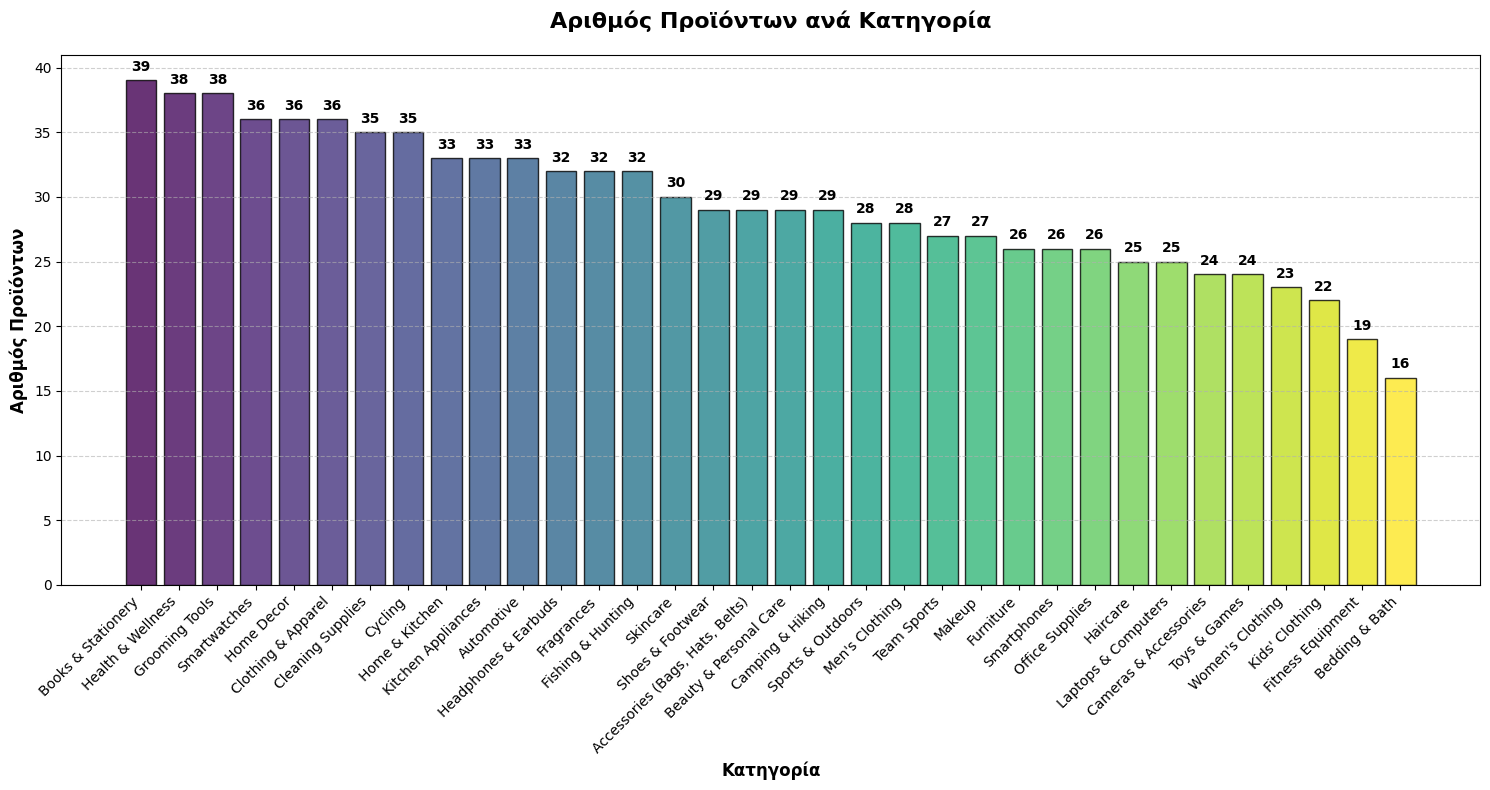

In [78]:
# Ερώτημα 7: Δημιουργία διαγράμματος ράβδων που δείχνει τον αριθμό των προϊόντων σε κάθε κατηγορία

# Συλλογή δεδομένων
category_counts = df["Category"].value_counts()

# Ρύθμιση μεγέθους και εμφάνισης διαγράμματος
plt.figure(figsize=(15, 8))

# Σχεδίαση διαγράμματος με τη χρήση της παλέτας χρωμάτων (Gradient)
# Χρησιμοποιούμε τη βιβλιοθήκη numpy (np) για τη διαβάθμιση των χρωμάτων
colors = plt.cm.viridis(np.linspace(0, 1, len(category_counts)))
bars = plt.bar(category_counts.index, category_counts.values, color=colors, edgecolor="black", alpha=0.8)

# Προσθήκη των αριθμών (Labels) πάνω σε κάθε μπάρα
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha="center", va="bottom", fontsize=10, fontweight="bold")

# Τίτλοι και ονομασίες αξόνων
plt.title("Αριθμός Προϊόντων ανά Κατηγορία", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Κατηγορία", fontsize=12, fontweight="bold")
plt.ylabel("Αριθμός Προϊόντων", fontsize=12, fontweight="bold")

# Ρυθμίσεις αξόνων και πλέγματος
plt.xticks(rotation=45, ha="right") # Κλίση στα ονόματα για να μη συμπίπτουν
plt.grid(axis="y", linestyle="--", alpha=0.6) # Διακριτικές γραμμές στο φόντο

# Τελική προσαρμογή και εμφάνιση του διαγράμματος ράβδων
plt.tight_layout()
plt.show()

<center><h3>8. Ιστόγραμμα των Τιμών των Προϊόντων</h3></center>

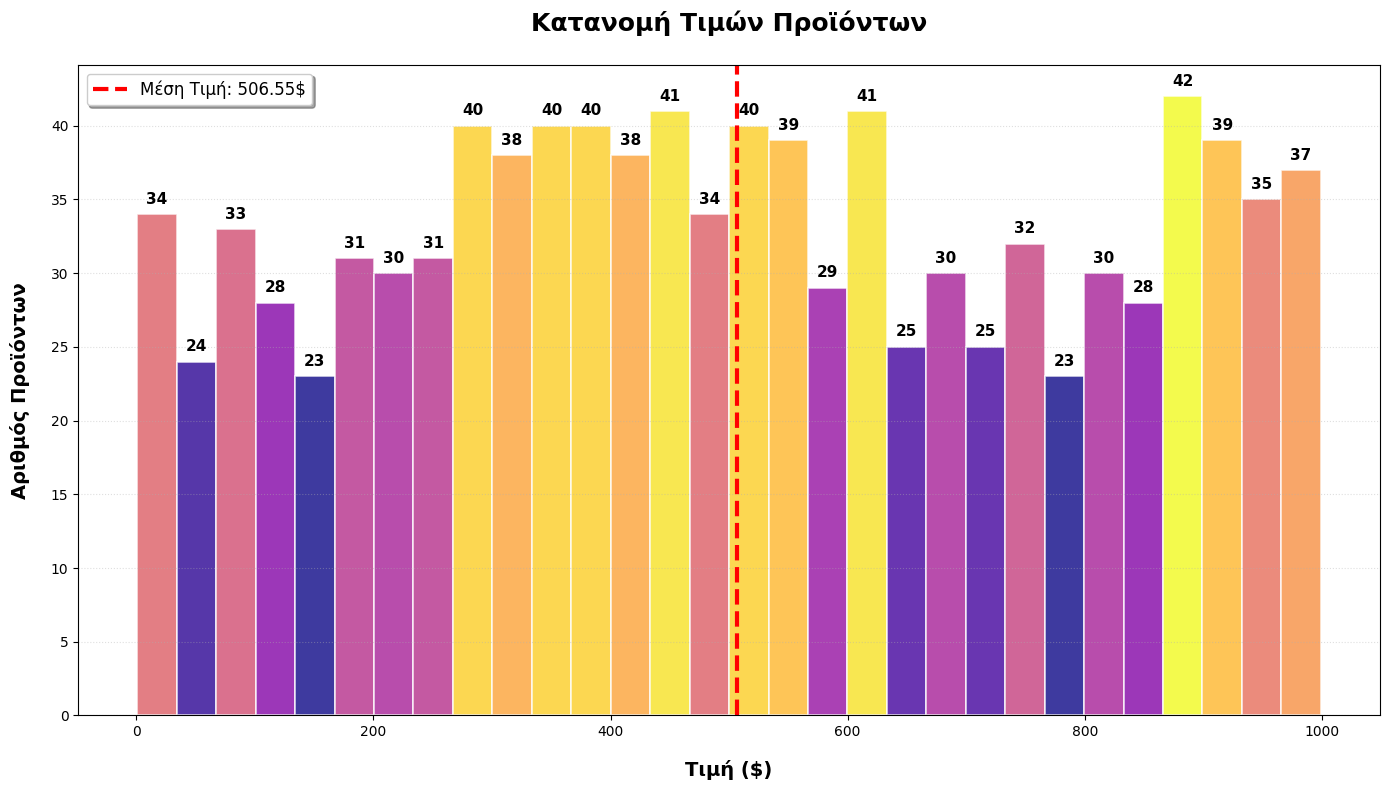

In [79]:
# Ερώτημα 8: Σχεδίαση ιστογράμματος των τιμών των προϊόντων

# Δημιουργία και ρύθμιση μεγέθους ιστογράμματος
fig, ax = plt.subplots(figsize=(14, 8))

# Σχεδίαση ιστογράμματος
# Χρησιμοποιούμε bins=30 για καλύτερη λεπτομέρεια
n, bins, patches = plt.hist(df["Price"], bins=30, edgecolor="white", linewidth=1.2, alpha=0.8)

# Σχεδίαση ιστογράμματος με τη χρήση του Gradient εφέ
fracs = n / n.max()
norm = plt.Normalize(fracs.min(), fracs.max())

for thisfrac, thispatch in zip(fracs, patches):
    color = plt.cm.plasma(norm(thisfrac)) # Χρήση της παλέτας plasma
    thispatch.set_facecolor(color)

# Προσθήκη labels πάνω στις μπάρες
for i in range(len(patches)):
    x_pos = patches[i].get_x() + patches[i].get_width()/2
    y_pos = n[i]
    if y_pos > 0: # Βάζουμε label μόνο αν η μπάρα δεν είναι μηδενική
        ax.text(x_pos, y_pos + 0.5, int(y_pos), ha="center", va="bottom", 
                fontsize=11, fontweight="bold")

# Προσθήκη γραμμής μέσης τιμής (Mean)
mean_price = df["Price"].mean()
plt.axvline(mean_price, color="red", linestyle="--", linewidth=3, label=f"Μέση Τιμή: {mean_price:.2f}$")

# Τίτλοι, πλέγμα και Labels
plt.title("Κατανομή Τιμών Προϊόντων", fontsize=18, fontweight="bold", pad=25)
plt.xlabel("Τιμή ($)", fontsize=14, fontweight="bold", labelpad=15)
plt.ylabel("Αριθμός Προϊόντων", fontsize=14, fontweight="bold", labelpad=15)
plt.grid(axis="y", linestyle=":", alpha=0.4)

# Προσθήκη υπομνήματος (Legend)
plt.legend(fontsize=12, shadow=True)

# Τελική προσαρμογή και εμφάνιση του ιστογράμματος
plt.tight_layout()
plt.show()

<center><h3>9. Ονόματα και Τιμές των 5 πιο Ακριβών Προϊόντων</h3></center>

In [80]:
# Ερώτημα 9: Εύρεση των 5 πιο ακριβών προϊόντων και εμφάνιση των ονομάτων και των τιμών τους
top_5_expensive = df.nlargest(5, "Price")[["Index", "Name", "Price"]]
print(top_5_expensive)

     Index                                     Name  Price
16      17  Digital Clock Lock Eco Premium Portable    999
370    371                 Ultra Cooker 360 Eco Pro    999
901    902        Fast Printer Fan Shaver Sense One    999
207    208                    Webcam Projector Oven    998
325    326       Premium Powerbank Radio Lite Prime    996


<center><h3>10. Ομαδοποίηση Προϊόντων κατά Brand και υπολογισμός Συνολικού Αποθέματος/Brand + Bar Plot</h3></center>


 Top 10 Brands ανά Απόθεμα
Brand
Lawson, Bass and Francis           999
Ray-Bullock                        999
White-Herman                       998
Jenkins, Doyle and Melendez        998
Snow, Cobb and Rosales             998
Frost-Richmond                     998
Finley Ltd                         997
Manning-Daniels                    996
Faulkner, Cervantes and Morales    995
Ayers-Day                          995
Name: Stock, dtype: int64


<Figure size 640x480 with 0 Axes>

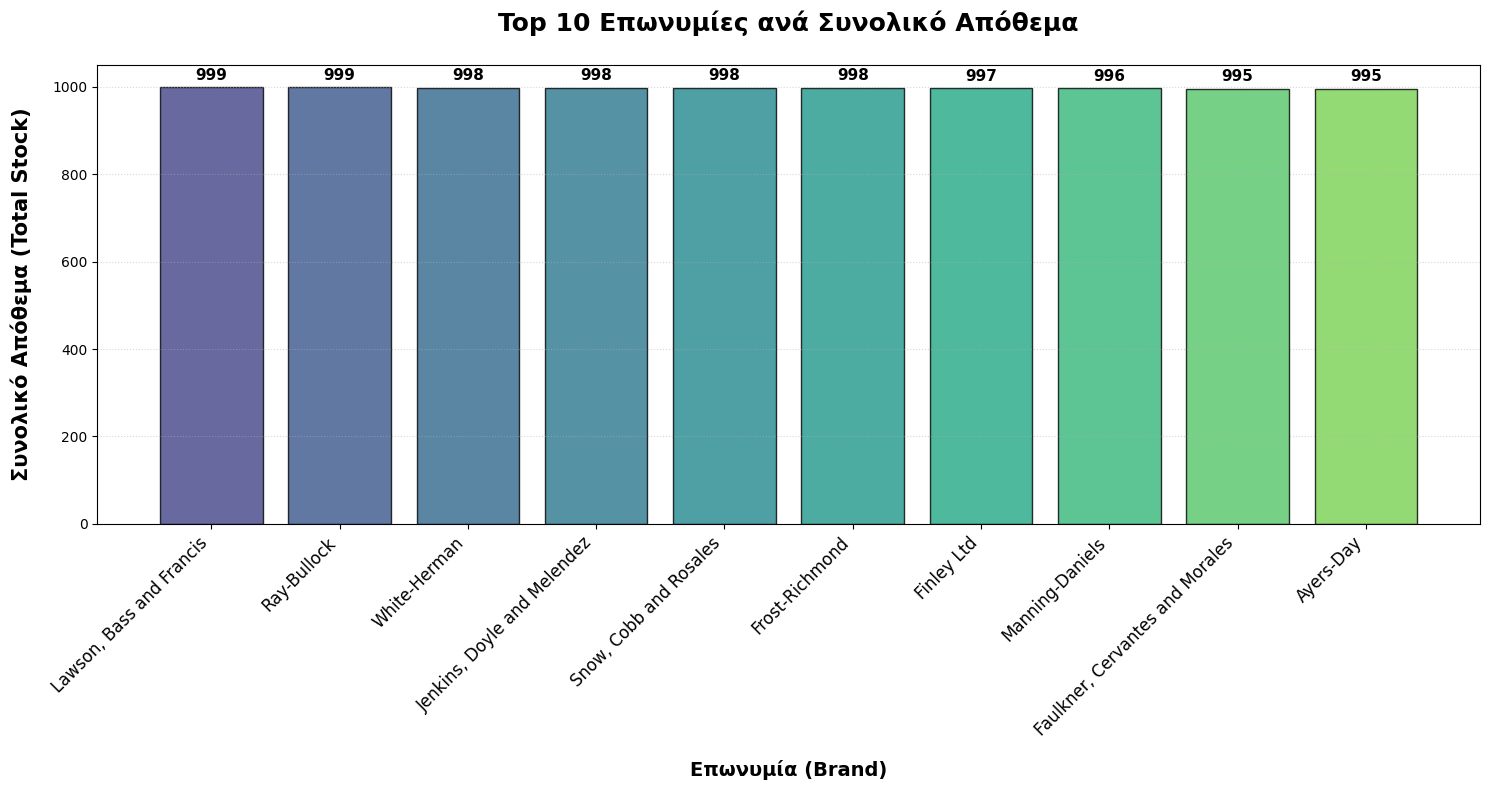

In [81]:
# Ερώτημα 10: Groupby Brand και Total Stock + bar plot

# Ομαδοποίηση (groupby) ανά Brand και υπολογισμός Total Stock/Brand
brand_stock = df.groupby("Brand")["Stock"].sum().sort_values(ascending=False)

# Επιλογή των 10 κορυφαίων Brands με το υψηλότερο συνολικό απόθεμα και εμφάνισή τους
top_10_brands = brand_stock.head(10)
print("\n Top 10 Brands ανά Απόθεμα")
print(top_10_brands)

# Καθαρισμός προηγούμενων σχημάτων και δημιουργία νέου σχήματος και άξονα
plt.clf()
fig, ax = plt.subplots(figsize=(15, 8))

# Σχεδίαση Bar Plot με Gradient εφέ
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_10_brands)))
bars = ax.bar(top_10_brands.index, top_10_brands.values, color = colors, edgecolor = "black", alpha = 0.8)

# Προσθήκη labels πάνω σε κάθε μπάρα
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha = "center", va = "bottom", fontsize = 11, fontweight = "bold")

# Τίτλοι και labels αξόνων
ax.set_title("Top 10 Επωνυμίες ανά Συνολικό Απόθεμα", fontsize = 18, fontweight = "bold", pad = 25)
ax.set_xlabel("Επωνυμία (Brand)", fontsize = 14, fontweight = "bold", labelpad = 15)
ax.set_ylabel("Συνολικό Απόθεμα (Total Stock)", fontsize = 15, fontweight = "bold", labelpad = 15)

# Ρυθμίσεις πλέγματος και αξόνων
plt.xticks(rotation = 45, ha = "right", fontsize = 12)
ax.grid(axis = "y", linestyle = ":", alpha = 0.5)

# Τελική προσαρμογή περιθωρίων και εμφάνιση του bar plot
plt.tight_layout()
plt.show()

<center><h3>11α. Κατηγοριοποίηση των Δεδομένων με βάση την Περιγραφή τους στα Είδη των Προϊόντων + Confusion Matrix</h3></center>

--- Συνολική Ακρίβεια (Accuracy): 3.00% ---

--- Classification Report ---
                                 precision    recall  f1-score   support

Accessories (Bags, Hats, Belts)       0.00      0.00      0.00         5
                     Automotive       0.00      0.00      0.00         6
         Beauty & Personal Care       0.00      0.00      0.00         7
                 Bedding & Bath       0.00      0.00      0.00         3
             Books & Stationery       0.06      0.11      0.07         9
          Cameras & Accessories       0.00      0.00      0.00         3
               Camping & Hiking       0.00      0.00      0.00         5
              Cleaning Supplies       0.00      0.00      0.00         6
             Clothing & Apparel       0.00      0.00      0.00         5
                        Cycling       0.00      0.00      0.00         9
              Fishing & Hunting       0.00      0.00      0.00         6
              Fitness Equipment       0.00      

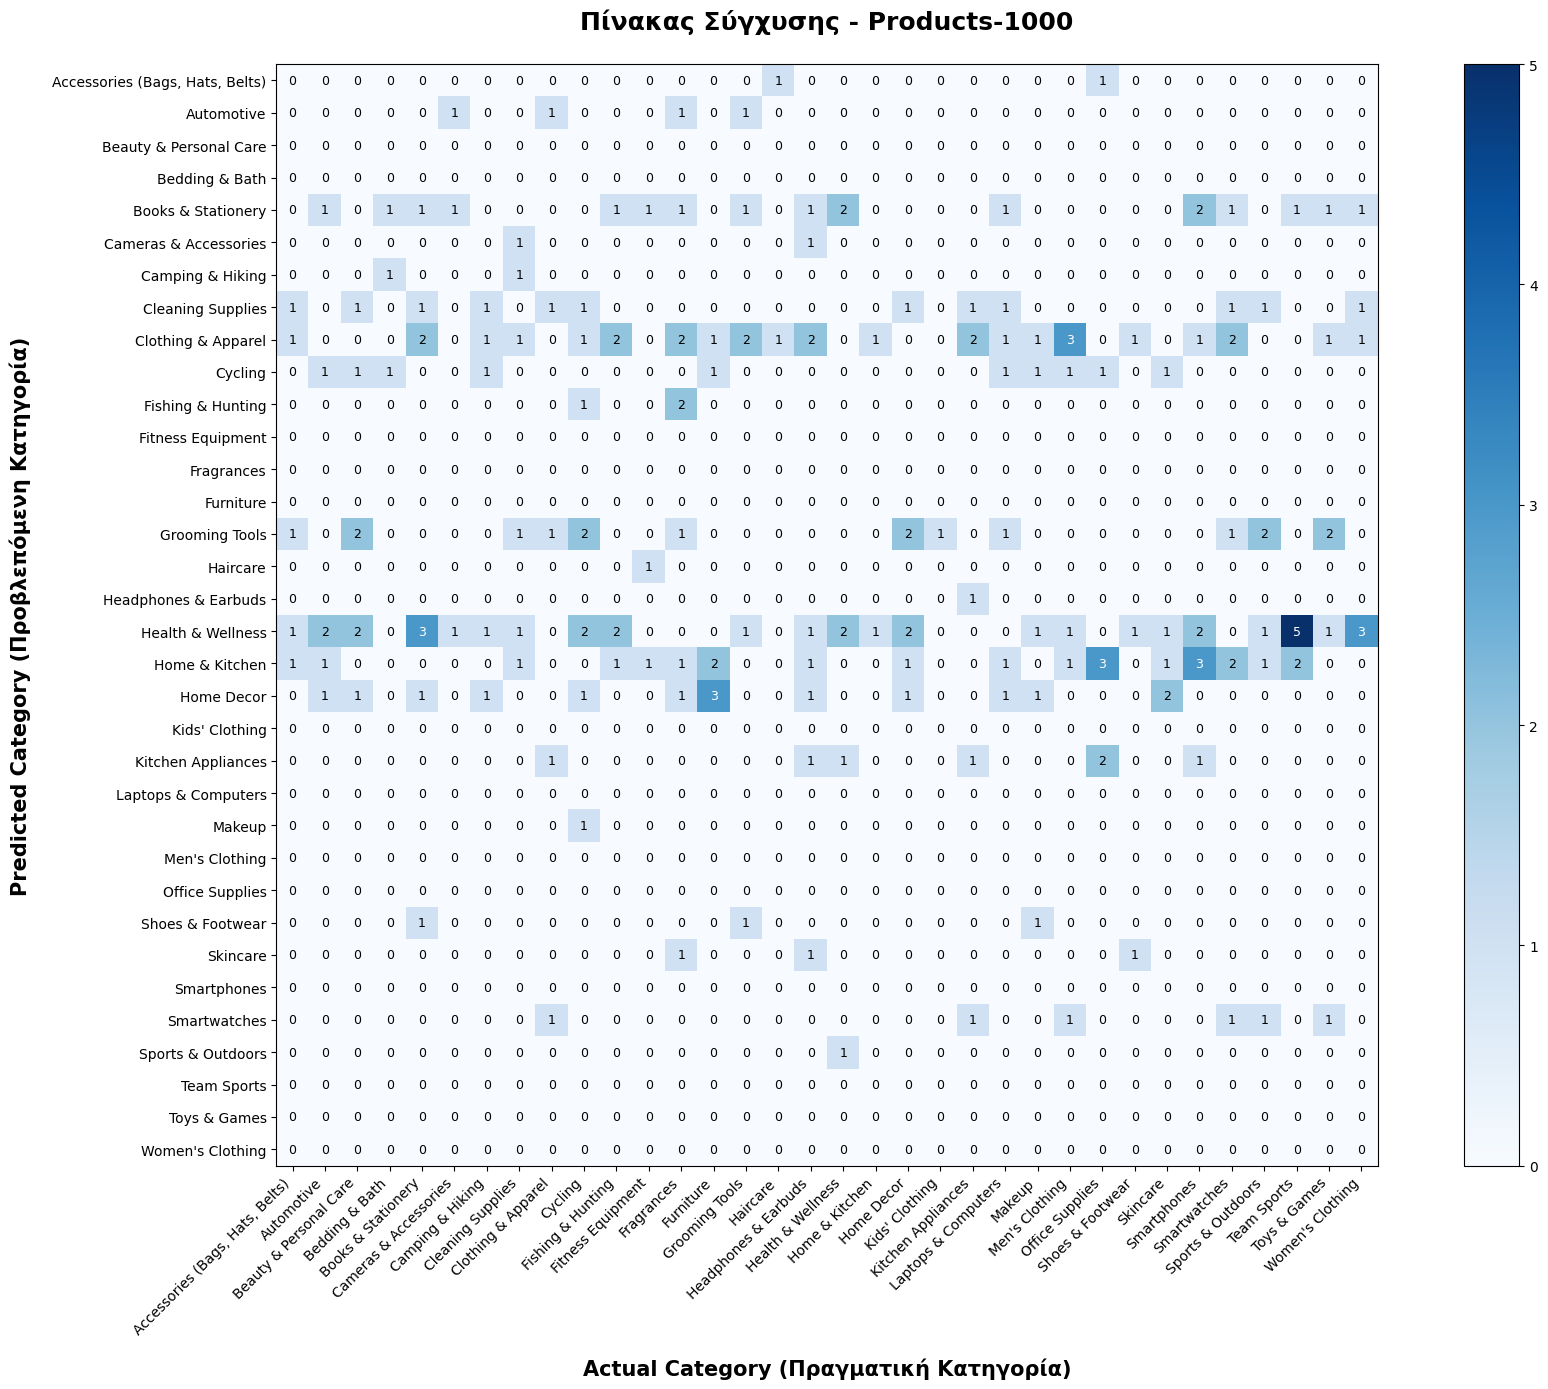

In [ ]:
# Ερώτημα 11α: Κατηγοριοποίηση δεδομένων βάσει της περιγραφής τους στα είδη των προϊόντων (naive nayes classifier) + confusion matrix

# Καθαρισμός δεδομένων (εξάλειψη non-available values)
df_ml = df[["Description", "Category"]].dropna()
X = df_ml["Description"]
y = df_ml["Category"]

# Διαχωρισμός σε training και testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Μετατροπή κειμένου σε αριθμούς (Vectorization)
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Εκπαίδευση Naive Bayes Classifier
clf = MultinomialNB()
clf.fit(X_train_tfidf, y_train)

# Πρόβλεψη
y_pred = clf.predict(X_test_tfidf)

# Υπολογισμός Performance Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"--- Συνολική Ακρίβεια (Accuracy): {accuracy:.2%} ---\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, zero_division=0))

# Δημιουργία του Πίνακα Σύγχυσης (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
classes = clf.classes_
cm_display = cm.T # Προβλεπόμενη κατηγορία στον άξονα Y και πραγματική κατηγορία στον άξονα X

# Ρυθμίσεις figure και τίτλος του confusion matrix
plt.figure(figsize=(22, 14))
im = plt.imshow(cm_display, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Πίνακας Σύγχυσης - Products-1000", fontsize=18, fontweight="bold", pad=25)

# Προσθήκη colorbar
plt.colorbar(im, fraction=0.046, pad=0.04)

# Δημιουργία μιας λίστας με τις θέσεις (indices) όπου θα τοποθετηθούν οι ετικέτες των κατηγοριών
tick_marks = np.arange(len(classes))

# Ρύθμιση ετικετών στον οριζόντιο άξονα (X): περιστροφή 45 μοιρών και στοίχιση δεξιά για αποφυγή επικάλυψης
plt.xticks(tick_marks, classes, rotation=45, ha='right', fontsize=10)

# Ρύθμιση ετικετών στον κάθετο άξονα (Y): ορισμός ονομάτων κατηγοριών και μεγέθους γραμματοσειράς
plt.yticks(tick_marks, classes, fontsize=10)

# Υπολογισμός ορίου (threshold) για την επιλογή χρώματος γραμματοσειράς (άσπρο ή μαύρο) ανάλογα με το φόντο
thresh = cm_display.max() / 2.
for i in range(cm_display.shape[0]):
    for j in range(cm_display.shape[1]):

        # Προσθήκη του αριθμού των προβλέψεων σε κάθε κελί και δυναμική ρύθμιση χρώματος για αναγνωσιμότητα
        plt.text(j, i, format(cm_display[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm_display[i, j] > thresh else "black",
                 fontsize=9)

# Καθορισμός των τίτλων και ετικετών (labels) των αξόνων
plt.ylabel('Predicted Category (Προβλεπόμενη Κατηγορία)', fontsize=15, fontweight="bold", labelpad=15)
plt.xlabel('Actual Category (Πραγματική Κατηγορία)', fontsize=15, fontweight="bold", labelpad=15)

# Τελική προσαρμογή περιθωρίων και εμφάνιση του confusion matrix
plt.tight_layout()
plt.show()

<h5><b>Επεξηγήσεις</b></h5>

<h7><span style="color: orange;"><b> 1. Συνολική Ακρίβεια (Accuracy): </b></span> 

- Η μετρική Accuracy αντιπροσωπεύει το ποσοστό των σωστών προβλέψεων επί του συνόλου των δεδομένων που χρησιμοποιήθηκαν για τον έλεγχο (Test Set).

- Ερμηνεία: Ένα Accuracy της τάξης του $3\%$ σημαίνει ότι σε 100 τυχαία προϊόντα, ο αλγόριθμος αναγνωρίζει σωστά την κατηγορία μόνο στα 3.

- Αιτιολόγηση: Η χαμηλή αυτή τιμή οφείλεται στο γεγονός ότι οι περιγραφές (Description) στο συγκεκριμένο αρχείο αποτελούνται από τυχαίες λέξεις χωρίς νοηματική συνάφεια με την κατηγορία, δυσκολεύοντας τον Naive Bayes να εντοπίσει στατιστικά σημαντικά μοτίβα.</h7>

<h7><span style="color: orange;"><b>2. Classification Report:</b></span>
Το Classification Report μας δίνει μια περιγραφή της απόδοσης ανά κατηγορία, χρησιμοποιώντας τέσσερις δείκτες:

- Precision (Πιστότητα): Η ικανότητα του μοντέλου να μην ταξινομεί λανθασμένα ένα προϊόν σε μια κατηγορία στην οποία δεν ανήκει.

- Recall (Ανάκληση): Η ικανότητα του μοντέλου να βρίσκει όλα τα προϊόντα που ανήκουν πραγματικά σε μια κατηγορία.

- F1-Score: Ο μέσος των Precision και Recall. Είναι ο καλύτερος δείκτης για να δούμε αν το μοντέλο ισορροπεί σωστά ανάμεσα στις δύο παραπάνω μετρικές.

- Support (Υποστήριξη): Ο αριθμός των πραγματικών δειγμάτων (γραμμών) που ανήκουν σε κάθε κατηγορία μέσα στο Test Set.

- <span style="color: yellow;">Παράδειγμα:</span> Κατηγορία "Smartwatches": 
- Support (8): Στο test set υπήρχαν 8 πραγματικά Smartwatches.
- Recall (0.12): Το μοντέλο εντόπισε σωστά μόνο 1 από τα 8 ($12.5\%$). Τα υπόλοιπα $7$ τα κατέταξε λανθασμένα αλλού.
- Precision (0.17): Όταν το μοντέλο έκανε την πρόβλεψη "Smartwatch", είχε δίκιο μόνο στο $17\%$ των περιπτώσεων. Αυτό σημαίνει ότι μπέρδεψε άλλα προϊόντα (π.χ. κατηγοριών Home & Kitchen, Grooming Tools) και τα ονόμασε λανθασμένα Smartwatches.
- F1-Score (0.14): Η χαμηλή τιμή δείχνει ότι ο αλγόριθμος αδυνατεί να διακρίνει τα Smartwatches από τις υπόλοιπες κατηγορίες.<h7>

<h7><span style="color: orange;"><b>3. Πίνακας Σύγχυσης (Confusion Matrix):</b></span> Ο πίνακας σύγχυσης που παρήγαγε ο κώδικας οπτικοποιεί τις παραπάνω μετρικές:

- Άξονας X (Horizontal): Πραγματική Κατηγορία (Actual).

- Άξονας Y (Vertical): Προβλεπόμενη Κατηγορία (Predicted).

- Κύρια Διαγώνιος: Σε αυτήν εμφανίζονται οι αριθμοί των σωστών προβλέψεων. Όμως, οι περισσότερες τιμές στη διαγώνιο είναι 0, γεγονός που εξηγεί το accuracy του $3\%$.

- Κελιά με "0": Δείχνουν ότι δεν υπήρξε καμία απολύτως συσχέτιση μεταξύ των συγκεκριμένων κατηγοριών.

- Σκούρα κελιά (π.χ. τιμή 5): Δείχνουν σημεία όπου το μοντέλο κάνει συστηματικά λάθη, μπερδεύοντας συχνά μια συγκεκριμένη κατηγορία με μια άλλη. <span style="color: yellow;">Παράδειγμα: </span> Πολλές προβλέψεις συγκεντρώνονται στην κατηγορία Health & Wellness ανεξάρτητα από το τι είναι το προϊόν. Αυτό σημαίνει ότι το μοντέλο έχει την τάση να προβλέπει πολύ συχνά την κατηγορία "Health & Wellness", ακόμη και όταν το προϊόν ανήκει σε τελείως διαφορετική κατηγορία (π.χ. Team Sports ή Books & Stationery). Αυτό συνήθως συμβαίνει όταν ορισμένες λέξεις-κλειδιά που υπάρχουν στις περιγραφές των προϊόντων "Health & Wellness" εμφανίζονται τυχαία και σε άλλες κατηγορίες, ή επειδή η συγκεκριμένη κατηγορία είχε ίσως πιο "γενικές" λέξεις στο training set που το μοντέλο τις θεωρεί πλέον χαρακτηριστικές για τα πάντα.</h7>

<center><h3>11β. Πιο συγκεκριμένη Κατηγοριοποίηση των Δεδομένων με βάση την Περιγραφή τους στα Είδη των Προϊόντων + Confusion Matrix</h3></center>

--- Συνολική Ακρίβεια (με Mapping): 18.50% ---

                 precision    recall  f1-score   support

    Accessories       0.00      0.00      0.00         5
Beauty & Health       0.21      0.37      0.27        41
 Books & Office       0.00      0.00      0.00        16
       Clothing       0.15      0.23      0.18        22
    Electronics       0.08      0.03      0.04        36
Hobbies & Games       0.00      0.00      0.00         6
 Home & Kitchen       0.21      0.39      0.27        31
         Sports       0.15      0.11      0.12        28
      Transport       0.50      0.07      0.12        15

       accuracy                           0.18       200
      macro avg       0.14      0.13      0.11       200
   weighted avg       0.16      0.18      0.15       200



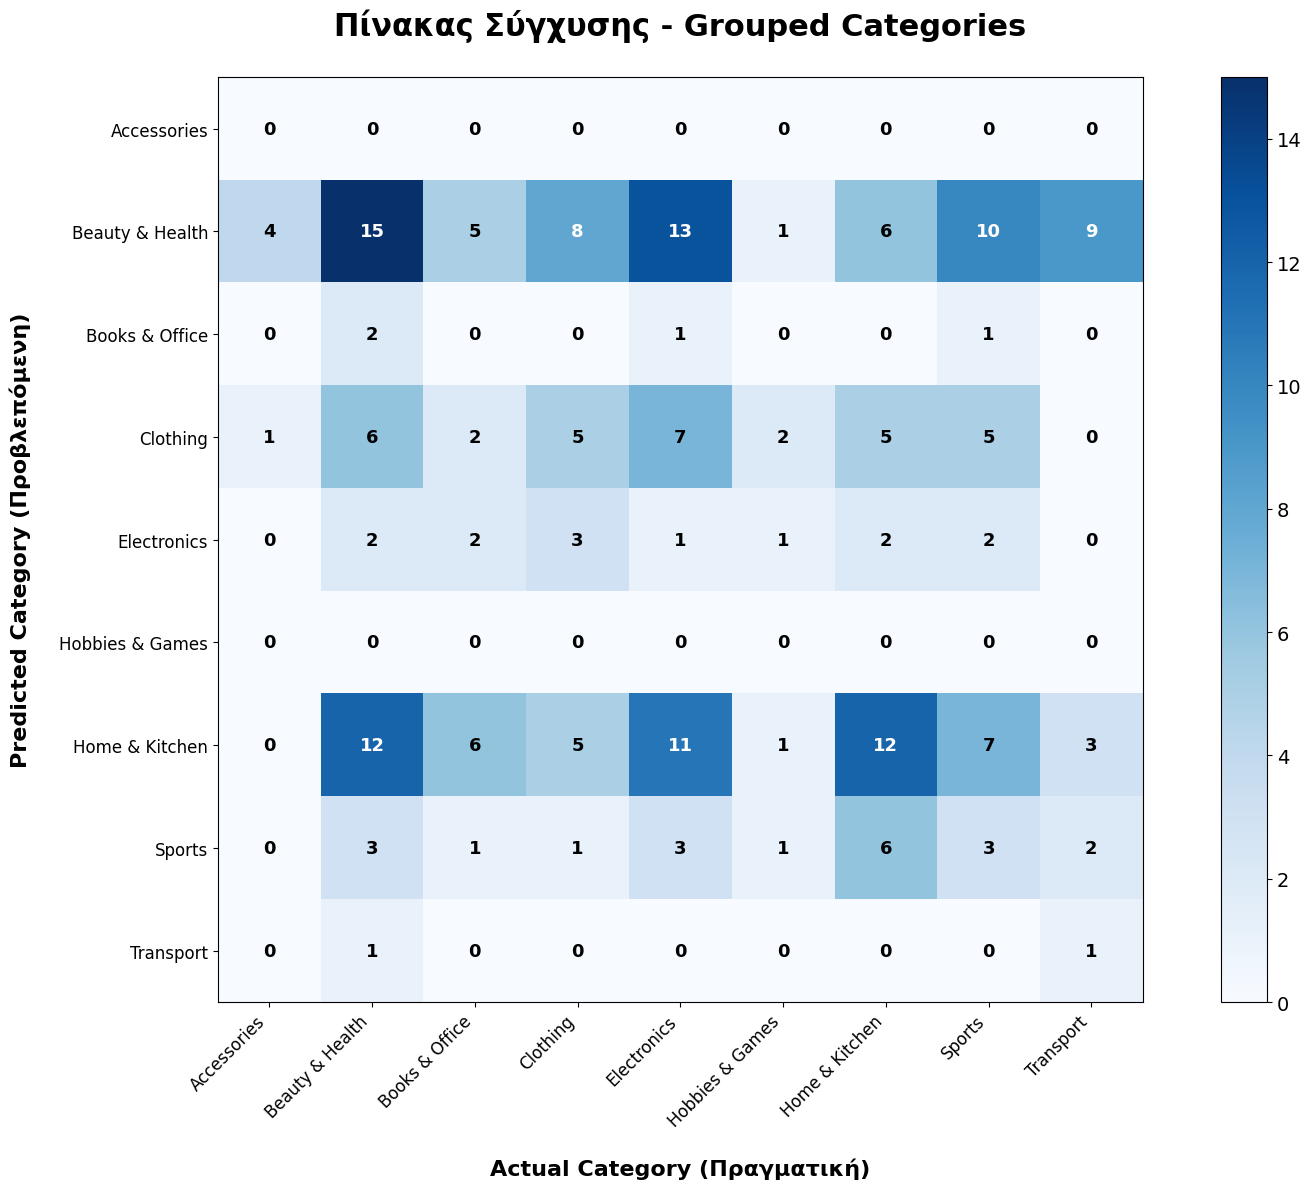

In [ ]:
# Ερώτημα 11β: Κατηγοριοποίηση με mapping και βελτιωμένη οπτικοποίηση

# Αναλυτικός και ξεκάθαρος διαχωρισμός κατηγοριών (Mapping)
mapping = {
    # Ένδυση (Clothing)
    'Clothing & Apparel': 'Clothing', "Men's Clothing": 'Clothing', 
    "Women's Clothing": 'Clothing', "Kids' Clothing": 'Clothing', 
    'Shoes & Footwear': 'Clothing',
    
    # Αξεσουάρ (Accessories)
    'Accessories (Bags, Hats, Belts)': 'Accessories',
    
    # Ηλεκτρονικά (Electronics)
    'Smartphones': 'Electronics', 'Smartwatches': 'Electronics', 
    'Laptops & Computers': 'Electronics', 'Cameras & Accessories': 'Electronics', 
    'Headphones & Earbuds': 'Electronics',
    
    # Σπίτι & Κουζίνα (Home)
    'Home Decor': 'Home & Kitchen', 'Home & Kitchen': 'Home & Kitchen', 
    'Bedding & Bath': 'Home & Kitchen', 'Kitchen Appliances': 'Home & Kitchen', 
    'Furniture': 'Home & Kitchen', 'Cleaning Supplies': 'Home & Kitchen',
    
    # Ομορφιά & Υγεία (Beauty)
    'Beauty & Personal Care': 'Beauty & Health', 'Health & Wellness': 'Beauty & Health',
    'Skincare': 'Beauty & Health', 'Fragrances': 'Beauty & Health', 
    'Makeup': 'Beauty & Health', 'Haircare': 'Beauty & Health', 
    'Grooming Tools': 'Beauty & Health',
    
    # Μεταφορικά Μέσα (Transport)
    'Automotive': 'Transport', 'Cycling': 'Transport',
    
    # Αθλητισμός (Sports)
    'Fitness Equipment': 'Sports', 'Sports & Outdoors': 'Sports',
    'Team Sports': 'Sports', 'Camping & Hiking': 'Sports',
    'Fishing & Hunting': 'Sports',
    
    # Χόμπις & Βιβλία (Hobbies & Office)
    'Toys & Games': 'Hobbies & Games',
    'Books & Stationery': 'Books & Office', 'Office Supplies': 'Books & Office'
}

# Προετοιμασία δεδομένων
df_ml = df[["Description", "Category"]].dropna()
df_ml['Grouped_Category'] = df_ml['Category'].map(mapping)

# Αφαίρεση τιμών που δεν περιλαμβάνονται στο mapping
df_ml = df_ml.dropna(subset=['Grouped_Category'])

X = df_ml["Description"]
y = df_ml['Grouped_Category']

# Διαχωρισμός σε training και testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorization (TF-IDF)
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Εκπαίδευση Naive Bayes Classifier
clf = MultinomialNB(alpha=0.1)
clf.fit(X_train_tfidf, y_train)

# Πρόβλεψη και metrics
y_pred = clf.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print(f"--- Συνολική Ακρίβεια (με Mapping): {accuracy:.2%} ---\n")
print(classification_report(y_test, y_pred, zero_division=0))

# Οπτικοποίηση πίνακα σύγχυσης
cm = confusion_matrix(y_test, y_pred)
classes = clf.classes_
cm_display = cm.T 

plt.figure(figsize=(20, 12))
im = plt.imshow(cm_display, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Πίνακας Σύγχυσης - Grouped Categories", 
          fontsize=22, fontweight="bold", pad=30)

# Ρύθμιση colorbar
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=14)

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45, ha='right', fontsize=12)
plt.yticks(tick_marks, classes, fontsize=12)

# Προσθήκη αριθμών στα κελιά
thresh = cm_display.max() / 2.
for i in range(cm_display.shape[0]):
    for j in range(cm_display.shape[1]):
        plt.text(j, i, format(cm_display[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm_display[i, j] > thresh else "black",
                 fontsize=13, fontweight="bold")

plt.ylabel('Predicted Category (Προβλεπόμενη)', fontsize=16, fontweight="bold", labelpad=20)
plt.xlabel('Actual Category (Πραγματική)', fontsize=16, fontweight="bold", labelpad=20)

# Τελική προσαρμογή των περιθωρίων και εμφάνιση του confusion matrix
plt.tight_layout()
plt.show()

<h5><span style="color: orange;"><b>Συμπέρασμα</b></span> 

Το συμπέρασμα από τη βελτίωση του Ερωτήματος 11 αναδεικνύει τη σημασία της προετοιμασίας των δεδομένων, καθώς η ακρίβεια αυξήθηκε από το αρχικό 3% στο 18.50%. Η χαμηλή αρχική επίδοση οφειλόταν στον κατακερματισμό των δεδομένων σε πολλές ασαφείς κατηγορίες, γεγονός που καθιστούσε τον πίνακα σύγχυσης εντελώς άμορφο και χωρίς διακριτή δομή. Με την εφαρμογή του mapping και την ομαδοποίηση σε 8 ευρύτερες θεματικές ενότητες, το μοντέλο απέκτησε τη δυνατότητα να εντοπίζει ισχυρότερα σημασιολογικά μοτίβα, αυξάνοντας την απόδοσή του κατά έξι φορές. Η βελτίωση αυτή, ορατή στη συγκέντρωση των σωστών προβλέψεων στον νέο πίνακα σύγχυσης, αποδεικνύει ότι η στρατηγική δόμηση των κατηγοριών και η μείωση του πληροφοριακού θορύβου είναι πιο καθοριστικές για την επιτυχία του αλγορίθμου από την πολυπλοκότητά του.</h5>

<center><h3>12. Bonus - Grocery Dataset</h3></center>

Το αρχείο φορτώθηκε επιτυχώς!

--- Συνολική Ακρίβεια (Accuracy): 62.68% ---

--- Classification Report ---
                              precision    recall  f1-score   support

           Bakery & Desserts       0.83      1.00      0.91         5
           Beverages & Water       0.80      0.86      0.83        28
                   Breakfast       0.00      0.00      0.00         5
                       Candy       0.87      0.72      0.79        36
           Cleaning Supplies       0.62      0.57      0.59        23
                      Coffee       0.73      0.76      0.74        21
                        Deli       0.00      0.00      0.00         6
                      Floral       1.00      1.00      1.00        17
                Gift Baskets       0.55      0.46      0.50        13
                   Household       0.80      0.94      0.86        17
  Kirkland Signature Grocery       0.20      0.12      0.15        17
Laundry Detergent & Supplies       0.00      0.00   

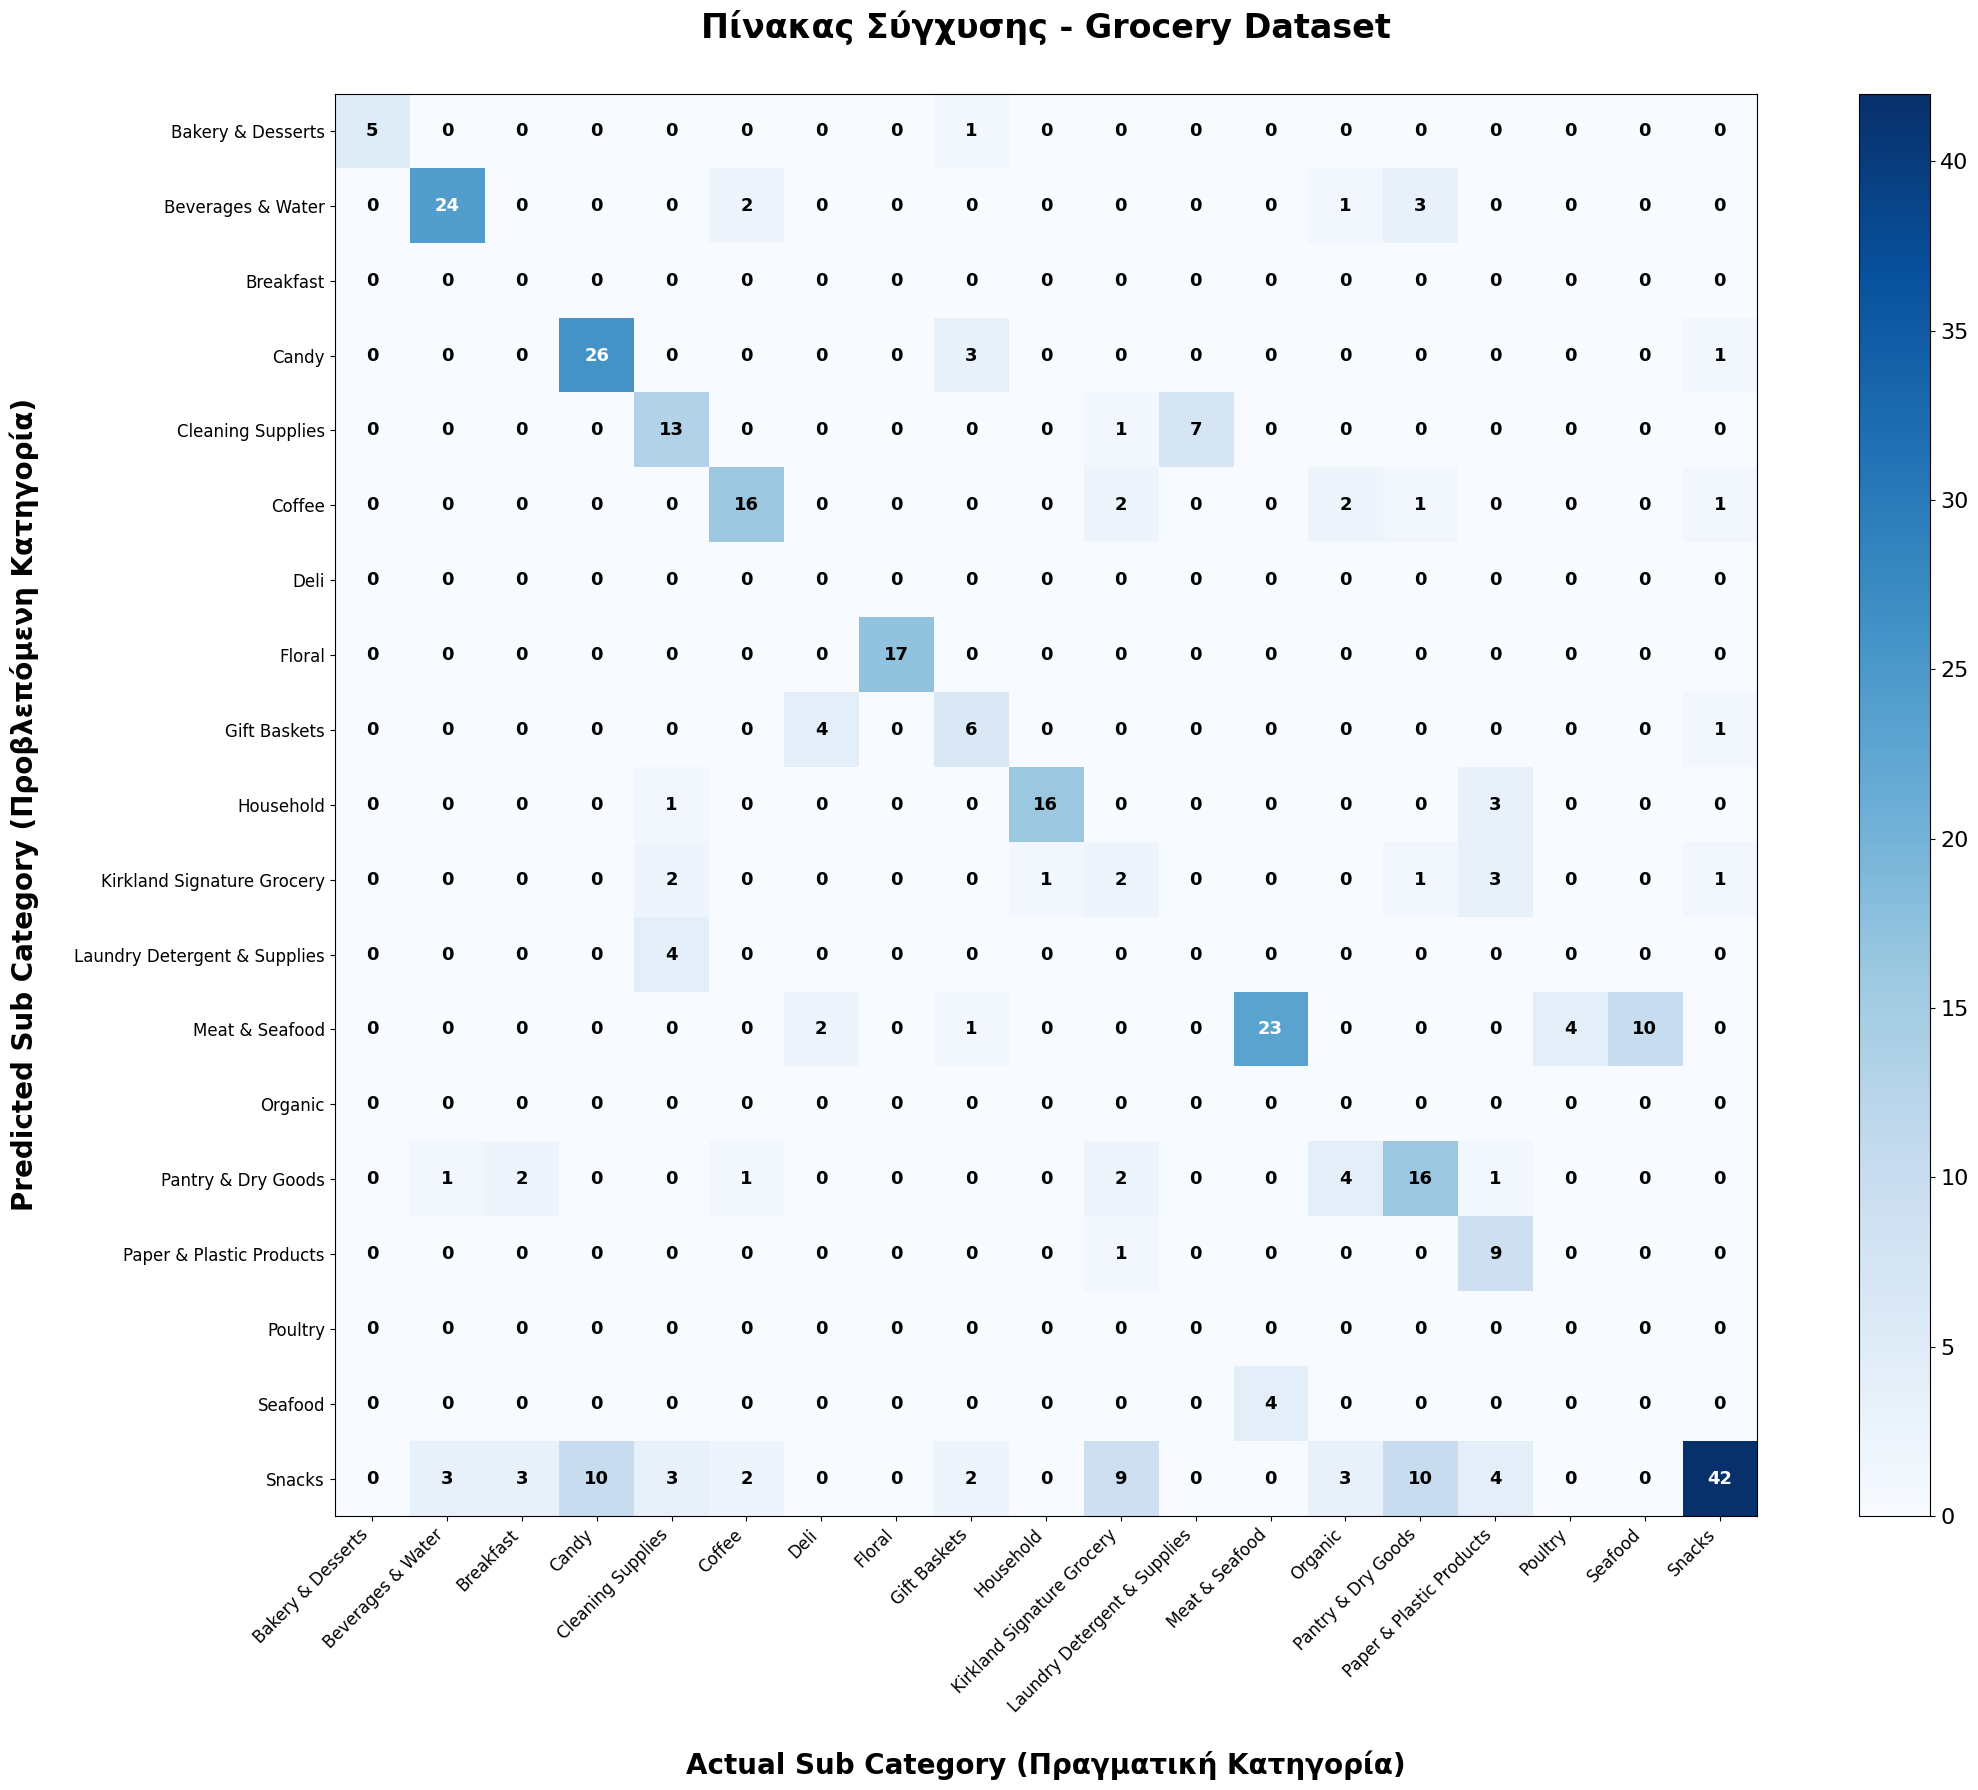

In [ ]:
# Ερώτημα 12: Bonus - Grocery Dataset

# Έλεγχος φόρτωσης του αρχείου (προϋπόθεση να βρίσκεται το Grocery Dataset στον ίδιο φάκελο με το αρχείο της εργασίας για να δουλέψει)
try:
    df_grocery = pd.read_csv("GroceryDataset.csv")
    print("Το αρχείο φορτώθηκε επιτυχώς!\n")
except FileNotFoundError:
    print("Σφάλμα: Το αρχείο GroceryDataset.csv δεν βρέθηκε στον φάκελο.")

# Προετοιμασία δεδομένων
df_ml2 = df_grocery[["Product Description", "Sub Category"]].dropna()
X2 = df_ml2["Product Description"]
y2 = df_ml2["Sub Category"]

# Διαχωρισμός σε training και testing sets (80/20)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Vectorization: 
# Χρήση ngram_range=(1, 2) για να αναγνωρίζει συνδυασμούς λέξεων (π.χ. "strawberry cheesecake")
# min_df=2 για αφαίρεση σπανίων λέξεων που προκαλούν θόρυβο
vectorizer2 = TfidfVectorizer(stop_words='english', 
                              ngram_range=(1, 2), 
                              min_df=2)
X_train_tfidf2 = vectorizer2.fit_transform(X_train2)
X_test_tfidf2 = vectorizer2.transform(X_test2)

# Εκπαίδευση Naive Bayes:
# Χρήση alpha=0.1 για καλύτερη απόδοση σε κείμενα περιγραφών
clf2 = MultinomialNB(alpha=0.1)
clf2.fit(X_train_tfidf2, y_train2)

# Πρόβλεψη
y_pred2 = clf2.predict(X_test_tfidf2)

# Metrics
accuracy2 = accuracy_score(y_test2, y_pred2)
print(f"--- Συνολική Ακρίβεια (Accuracy): {accuracy2:.2%} ---\n")
print("--- Classification Report ---")
print(classification_report(y_test2, y_pred2, zero_division=0))

# Οπτικοποίηση του πίνακα σύγχυσης
cm2 = confusion_matrix(y_test2, y_pred2)
classes2 = clf2.classes_
cm_display2 = cm2.T 

# Μέγεθος διαγράμματος
plt.figure(figsize=(26, 18))
im2 = plt.imshow(cm_display2, interpolation='nearest', cmap=plt.cm.Blues)

# Ονομασία και χαρακτηριστικά τίτλου
plt.title("Πίνακας Σύγχυσης - Grocery Dataset", 
          fontsize=24, fontweight="bold", pad=40)

# Ρύθμιση colorbar
cbar = plt.colorbar(im2, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=16)

# Ρύθμιση ετικετών (Ticks)
tick_marks2 = np.arange(len(classes2))
plt.xticks(tick_marks2, classes2, rotation=45, ha='right', fontsize=12) 
plt.yticks(tick_marks2, classes2, fontsize=12)

# 9. Προσθήκη αριθμών με δυναμικό χρώμα
thresh2 = cm_display2.max() / 2.
for i in range(cm_display2.shape[0]):
    for j in range(cm_display2.shape[1]):
        plt.text(j, i, format(cm_display2[i, j], 'd'),
                 ha="center", va="center",
                 # Άσπρο χρώμα αριθμών στα σκούρα κελιά και μαύρο στα ανοιχτά
                 color="white" if cm_display2[i, j] > thresh2 else "black",
                 fontsize=13, fontweight='bold')

# Ετικέτες αξόνων
plt.ylabel('Predicted Sub Category (Προβλεπόμενη Κατηγορία)', fontsize=20, fontweight="bold", labelpad=25)
plt.xlabel('Actual Sub Category (Πραγματική Κατηγορία)', fontsize=20, fontweight="bold", labelpad=25)

# Τελική προσαρμογή των περιθωρίων και εμφάνιση του confusion matrix
plt.tight_layout()
plt.show()

<h5><b>Σύγκριση Αποτελεσμάτων: Ερώτημα 11α (Products-1000) VS Ερώτημα 12 (Grocery Dataset)</b></h5>

<h7><span style="color: orange;"><b> 1. Συνολική Ακρίβεια (Accuracy): </b></span> 
- Ερώτημα 11 (Products-1000): Η ακρίβεια ήταν μόλις $3.00\%$. Το μοντέλο "μάντευε" στην τύχη, καθώς οι λέξεις στις περιγραφές δεν είχαν σχεδόν καμία λογική σύνδεση με τις κατηγορίες.

- Ερώτημα 12 (Grocery Dataset): Η ακρίβεια αυξήθηκε ραγδαία στο $62.68\%$. Αυτή η μεγάλη διαφορά αποδεικνύει ότι οι περιγραφές του Dataset (Product Description) περιέχουν ουσιαστική πληροφορία που επιτρέπει στον αλγόριθμο να μάθει μοτίβα. </h7>

<h7><span style="color: orange;"><b> 2. Ποιότητα Δεδομένων και Σημασιολογία: </b></span>
- Στο Ερώτημα 11, το dataset είχε θόρυβο (noise). Λέξεις που εμφανίζονταν σε μια κατηγορία εμφανίζονταν τυχαία και σε άλλες, με αποτέλεσμα το μοντέλο να μπερδεύεται.

- Στο Ερώτημα 12, οι περιγραφές είναι συγκεκριμένες (π.χ. "Sparkling orange and pomegranate beverage11.15 fl oz cans4 boxes of 6 cans24 total cans"). Έτσι, ο αλγόριθμος TF-IDF κατάφερε να απομονώσει αυτές τις λέξεις-κλειδιά και να τις συσχετίσει επιτυχημένα με τις υποκατηγορίες (Sub Categories).</h7>

<h7><span style="color: orange;"><b>3. Ανάλυση Classification Reports</b></span>

Απόδοση ανά Κατηγορία (F1-score)
- Ερώτημα 11: Παρατηρείται πλειοψηφία των κατηγοριών με $0.00$ F1-score. Συγκεκριμένα, το μοντέλο "μαντεύει" μόνο σε ελάχιστες κατηγορίες (π.χ. Books & Stationery, Home Decor) με εξαιρετικά χαμηλά ποσοστά, δείχνοντας πλήρη αδυναμία μάθησης.

- Ερώτημα 12: Παρατηρείται εντυπωσιακή βελτίωση. Κατηγορίες όπως το Floral ($1.00$), το Bakery & Desserts ($0.91$) και το Household ($0.86$) προβλέπονται σχεδόν τέλεια σύμφωνα με τα F1-score τους. Ακόμη και κατηγορίες με πολύ "θόρυβο" όπως τα Snacks έχουν πλέον υψηλό Recall ($0.91$), δείχνοντας ότι το μοντέλο εντοπίζει τις περισσότερες περιπτώσεις τους.

Ισορροπία Precision και Recall

- Ερώτημα 11: Οι μετρικές είναι εντελώς ασύμβατες (Weighted Avg Precision $0.02$ / Recall $0.03$). Η υψηλή συγκέντρωση λαθών σε κατηγορίες όπως το "Health & Wellness" δείχνει ότι το μοντέλο είχε ισχυρή προκατάληψη (bias) λόγω έλλειψης χαρακτηριστικών λέξεων.

- Ερώτημα 12: Οι μετρικές είναι πολύ πιο ισορροπημένες (Weighted Avg Precision $0.59$ / Recall $0.63$). Αυτό αποδεικνύει ότι οι περιγραφές των προϊόντων στο Grocery Dataset περιέχουν ουσιαστική πληροφορία που επιτρέπει στον αλγόριθμο TF-IDF να διακρίνει τις κατηγορίες μεταξύ τους.

<h7><span style="color: orange;"><b>4. Ανάλυση Πινάκων Σύγχυσης (Confusion Matrix)</b></span>

Η Εμφάνιση της "Διαγωνίου Επιτυχίας"
- Ερώτημα 11: Ο πίνακας παρουσιάζει μια εικόνα πλήρους διάχυσης. Δεν υπάρχει καμία ορατή διαγώνιος, γεγονός που μαρτυρά ότι το μοντέλο αδυνατεί να ταυτίσει τις περιγραφές με τις σωστές κατηγορίες. Οι περισσότερες προβλέψεις είναι διασκορπισμένες τυχαία σε όλο το γράφημα.

- Ερώτημα 12: Παρατηρούμε μια ξεκάθαρη και έντονη διαγώνιο γραμμή. Αυτό αποτελεί την οπτική απόδειξη ότι το μοντέλο προβλέπει σωστά την πλειοψηφία των προϊόντων. Για παράδειγμα, στην κατηγορία Snacks, το μοντέλο πέτυχε 42 σωστές προβλέψεις, δημιουργώντας ένα σκούρο μπλε κελί στη διαγώνιο.

Συσσώρευση και Κατανομή Λαθών
- Ερώτημα 11: Παρατηρείται μια λανθασμένη συγκέντρωση λαθών προς την κατηγορία "Health & Wellness". Το μοντέλο εμφάνιζε "μεροληψία" (bias), κατατάσσοντας τυχαία προϊόντα εκεί, επειδή οι περιγραφές ήταν ασαφείς και δεν παρείχαν διακριτά χαρακτηριστικά.

- Ερώτημα 12: Τα λάθη είναι πλέον πολύ περιορισμένα και "λογικά". Για παράδειγμα, υπάρχει ένα μικρό μπέρδεμα ανάμεσα στο "Meat & Seafood" και το "Seafood" (4 λάθη), το οποίο είναι αναμενόμενο καθώς οι περιγραφές τους μοιράζονται κοινές λέξεις-κλειδιά.

Σημασιολογική Συσχέτιση
- Ερώτημα 11: Οι περιγραφές στο πρώτο dataset δεν περιείχαν λέξεις που να χαρακτηρίζουν την κατηγορία τους, οδηγώντας σε ακρίβεια μόλις 3.00%.

- Ερώτημα 12: Στο Grocery Dataset, οι λέξεις-κλειδιά (π.χ. "Beverages", "Candy", "Coffee") είναι ισχυρές και μοναδικές. Αυτό επέτρεψε στον Naive Bayes να "χτίσει" μια ισχυρή πιθανοτική σχέση, ανεβάζοντας την ακρίβεια στο $62.68\%$.

<h7><span style="color: orange;"><b>5. Συμπέρασμα</b></span> 

Η σύγκριση των δύο πειραμάτων αποδεικνύει ότι η επιτυχία ενός μοντέλου Μηχανικής Μάθησης εξαρτάται πρωτίστως από την ποιότητα των δεδομένων (Data Quality) και λιγότερο από τον ίδιο τον αλγόριθμο. Ο Naive Bayes, αν και απλός αλγόριθμος, απέδωσε εξαιρετικά στο Grocery Dataset επειδή υπήρχε σαφής σημασιολογική σχέση μεταξύ περιγραφής και κατηγορίας προϊόντος.<h7>